In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
df = pd.read_csv("/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv")
print("Shape:", df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [ ]:
import pydicom
import cv2
from tqdm import tqdm

image_id = df["image_id"].unique()
np.random.seed(42)
select_ids=np.random.choice(image_id,2000,replace=False)
output_dir = "/kaggle/working/images3000"
os.makedirs(output_dir, exist_ok=True)


input_dir = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

for img_id in tqdm(select_ids):
    
    dicom_path = os.path.join(input_dir, f"{img_id}.dicom")
    
    ds = pydicom.dcmread(dicom_path)
    
    image = ds.pixel_array.astype(np.float32)
    
    image -= image.min()
    if image.max() != 0:
        image /= image.max() 
    image *= 255.0
    
    image = image.astype(np.uint8)
    save_path = os.path.join(output_dir, f"{img_id}.png")
    cv2.imwrite(save_path, image)



100%|██████████| 2000/2000 [45:24<00:00,  1.36s/it] 


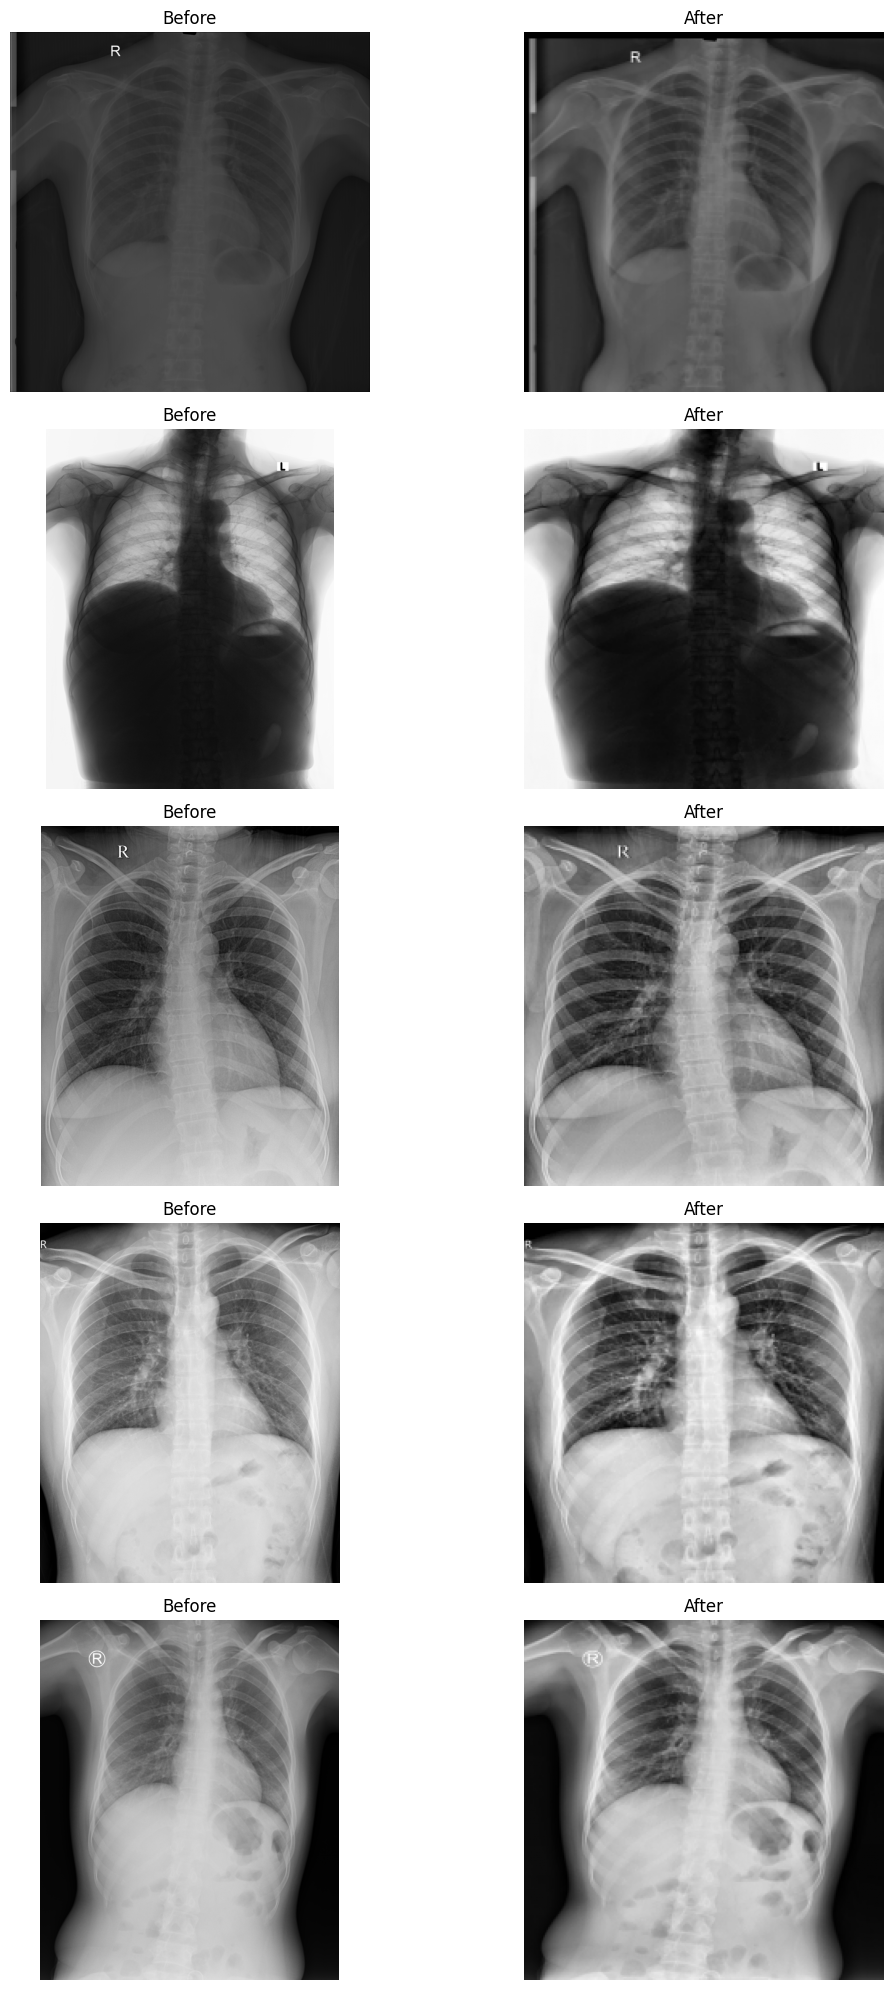

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import albumentations as A


output_dir = "/kaggle/working/images3000"
target_size = 224

image_files = os.listdir(output_dir)
if len(image_files) == 0:
    raise ValueError("No images found in the output_dir!")

first_image = image_files[0]
remaining_images = image_files[1:]
random_images = random.sample(remaining_images, 4)
selected_images = [first_image] + random_images


augment = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),
    A.Affine(
        scale=(0.98, 1.02),
        translate_percent=(0.02, 0.02),
        rotate=0,
        p=0.3
    ),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2)
])


def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None

    img_blur = cv2.GaussianBlur(img, (3, 3), 0.3)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_blur)

    _, thresh = cv2.threshold(img_clahe, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img_cropped = img_clahe[y:y+h, x:x+w]
    else:
        img_cropped = img_clahe

    img_resized = cv2.resize(
        img_cropped,
        (target_size, target_size),
        interpolation=cv2.INTER_AREA
    )

    augmented = augment(image=img_resized)
    img_aug = augmented["image"]

    img_final = img_aug.astype(np.float32) / 255.0

    return img_final, img

plt.figure(figsize=(12, 20))

for i, file in enumerate(selected_images):
    sample_path = os.path.join(output_dir, file)
    processed_img, original_img = preprocess_image(sample_path)

    if processed_img is None:
        continue

    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(original_img, cmap="gray")
    plt.title("Before")
    plt.axis("off")

    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(processed_img, cmap="gray")
    plt.title("After")
    plt.axis("off")

plt.tight_layout()
plt.show()


YOLO annotation conversion complete.


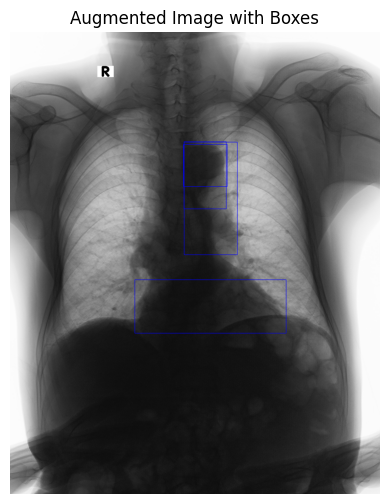

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import shutil

IMAGE_DIR = "/kaggle/working/images3000"
CSV_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
YOLO_LABEL_DIR = "/kaggle/working/yolo_labels"

if os.path.exists(YOLO_LABEL_DIR):
    shutil.rmtree(YOLO_LABEL_DIR)
os.makedirs(YOLO_LABEL_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
available_images = set(os.listdir(IMAGE_DIR))

for image_id in df['image_id'].unique():
    image_name = image_id + ".png"

    if image_name not in available_images:
        continue

    img_path = os.path.join(IMAGE_DIR, image_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]
    image_data = df[df['image_id'] == image_id]

    yolo_lines = []

    for _, row in image_data.iterrows():
        class_id = int(row['class_id'])

        if class_id == 14:
            continue

        if pd.isna(row['x_min']) or pd.isna(row['y_min']) \
           or pd.isna(row['x_max']) or pd.isna(row['y_max']):
            continue

        x_min = row['x_min']
        y_min = row['y_min']
        x_max = row['x_max']
        y_max = row['y_max']

        xc = ((x_min + x_max) / 2) / w
        yc = ((y_min + y_max) / 2) / h
        bw = (x_max - x_min) / w
        bh = (y_max - y_min) / h

        yolo_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    label_path = os.path.join(YOLO_LABEL_DIR, image_name.replace(".png", ".txt"))

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

print("YOLO annotation conversion complete.")

def load_yolo_boxes(label_path):
    bboxes = []
    class_labels = []
    with open(label_path, 'r') as file:
        for line in file.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            bbox = list(map(float, parts[1:]))
            bboxes.append(bbox)
            class_labels.append(class_id)
    return bboxes, class_labels

def augment(image, bboxes, class_labels):
    return {"image": image, "bboxes": bboxes, "class_labels": class_labels}

def draw_yolo_boxes(image, bboxes, class_labels):
    for bbox in bboxes:
        x_center, y_center, width, height = bbox
        x_min = int((x_center - width / 2) * image.shape[1])
        y_min = int((y_center - height / 2) * image.shape[0])
        x_max = int((x_center + width / 2) * image.shape[1])
        y_max = int((y_center + height / 2) * image.shape[0])
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
    return image

image_name = "ef52e83e7d040c6fcb278fa3ee8ad35a.png"
img_path = os.path.join(IMAGE_DIR, image_name)
label_path = os.path.join(YOLO_LABEL_DIR, image_name.replace(".png", ".txt"))

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not found. Check path.")

bboxes, class_labels = load_yolo_boxes(label_path)

augmented = augment(image=img, bboxes=bboxes, class_labels=class_labels)

aug_img = augmented["image"]
aug_boxes = augmented["bboxes"]
aug_labels = augmented["class_labels"]

aug_img = draw_yolo_boxes(aug_img, aug_boxes, aug_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Augmented Image with Boxes")
plt.show()


In [19]:
import albumentations as A
import cv2

augment = A.Compose(
    [
        A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=0.5
        ),
        A.Affine(
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

print("Augmentation pipeline ready.")


Augmentation pipeline ready.


In [ ]:
import os
import random
import shutil

IMAGE_DIR = "/kaggle/working/images3000"
LABEL_DIR = "/kaggle/working/yolo_labels"

BASE_DIR = "/kaggle/working/yolo_dataset"

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
TRAIN_LABEL_DIR = os.path.join(BASE_DIR, "train/labels")
VAL_IMG_DIR = os.path.join(BASE_DIR, "val/images")
VAL_LABEL_DIR = os.path.join(BASE_DIR, "val/labels")

for folder in [TRAIN_IMG_DIR, TRAIN_LABEL_DIR, VAL_IMG_DIR, VAL_LABEL_DIR]:
    os.makedirs(folder, exist_ok=True)

images = []
for file in os.listdir(LABEL_DIR):
    if file.endswith(".txt"):
        image_name = file.replace(".txt", ".png")
        image_path = os.path.join(IMAGE_DIR, image_name)
        if os.path.exists(image_path):
            images.append(image_name)

print(f"Total valid images: {len(images)}")

random.seed(42)
random.shuffle(images)

split_index = int(0.7 * len(images))
train_images = images[:split_index]
val_images = images[split_index:]

for image_name in train_images:
    shutil.copy(os.path.join(IMAGE_DIR, image_name), TRAIN_IMG_DIR)
    shutil.copy(os.path.join(LABEL_DIR, image_name.replace(".png", ".txt")), TRAIN_LABEL_DIR)

for image_name in val_images:
    shutil.copy(os.path.join(IMAGE_DIR, image_name), VAL_IMG_DIR)
    shutil.copy(os.path.join(LABEL_DIR, image_name.replace(".png", ".txt")), VAL_LABEL_DIR)

print("\nSplit Complete")
print(f"Train images: {len(train_images)} ({len(train_images)/len(images)*100:.2f}%)")
print(f"Val images: {len(val_images)} ({len(val_images)/len(images)*100:.2f}%)")

Total valid images: 2000

Split Complete
Train images: 1400 (70.00%)
Val images: 600 (30.00%)
